# Demonstration of LCA-FMU


In [66]:
# Import packages
# General imports
from pathlib import Path
import importlib.metadata as ilm
import subprocess
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fmpy import read_model_description, simulate_fmu

# Use a colorblind-focused plotting palette for all examples
plt.style.use("tableau-colorblind10")

# LCA-FMU imports
from scripts.run_fmu import inspect_fmu, simulate_system_fmu, sequential_cosim

In [67]:
# Resolve project root and file paths
# Verify project root and FMU directory exists
cwd = Path.cwd().resolve()
if (cwd / "fmu").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "fmu").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise RuntimeError("Could not locate project root containing the fmu/ folder")

# Set FMU file paths
FMU_DIR = PROJECT_ROOT / "fmu"
PV_WECC_FMU = FMU_DIR / "PV_System_WECC.fmu"
PV_MRO_FMU = FMU_DIR / "PV_System_MRO.fmu"
LCA_WECC_FMU = FMU_DIR / "PvWecc_Ipcc_v1.0.fmu"
LCA_MRO_FMU = FMU_DIR / "PvMro_Ipcc_v1.0.fmu"

# Define time constants
SECONDS_PER_DAY = 24 * 3600
SECONDS_PER_YEAR = 365 * SECONDS_PER_DAY

# Print directories
print(f"Project root: {PROJECT_ROOT}")
print(f"FMU directory: {FMU_DIR}")

Project root: C:\Users\khinkelm\git\Brightcon2026
FMU directory: C:\Users\khinkelm\git\Brightcon2026\fmu


## Example 1: One FMU
Goal: load one FMU, simulate 24 hours, and plot requested power outputs (unit: W).
FMU: PV_System_WECC -- Modelica system model

Plotted signals (positive = imported/generated, negative = consumed/exported):
- PGriRea.y
- pv.P
- loa.P


In [68]:
# View some fmu details
inspect_fmu(PV_WECC_FMU, max_vars=12)


=== PV_System_WECC.fmu ===
Model name: PV_System_WECC
FMI version: 2.0
Co-Simulation: True
I/O/parameter variables shown: 12 of 69
  - parameter n
  - parameter i
  - parameter priGriBuy
  - parameter priGriSel
  - parameter ratCO2
  - parameter n_pv
  - parameter PV_surface
  - parameter etaPV
  - parameter W_m2_nominal
  - parameter n_bess
  - parameter etaBatDis
  - parameter etaBatChr


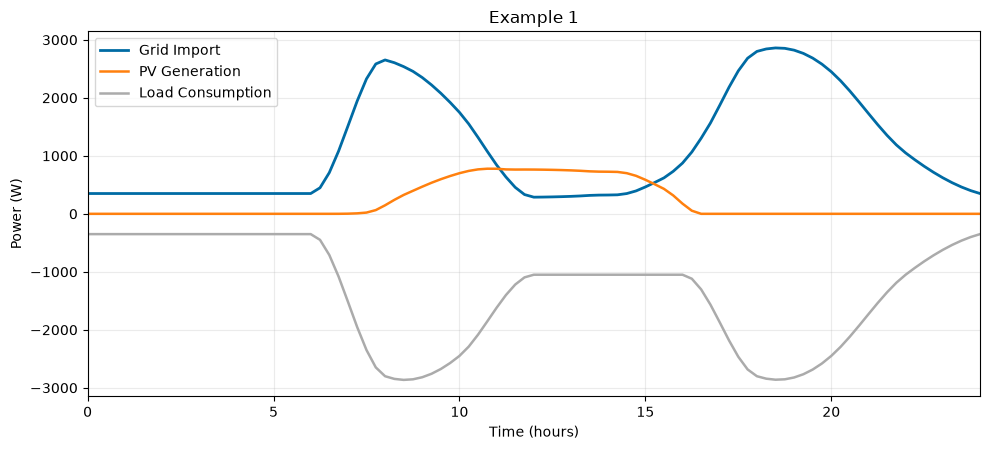

Example 1 summary
Samples: 97
Final PGriRea.y: 350.000 W
Final pv.P:      0.000 W
Final loa.P:     -350.000 W


In [69]:
# Simulate the model 
res1 = simulate_system_fmu(
    fmu_path=PV_WECC_FMU,
    start_s=0.0,
    stop_s=SECONDS_PER_DAY,
    outputs=["PGriRea.y", "pv.P", "loa.P"],
    output_interval_s=900.0,
    start_values={"n_pv": 1.0},
)

# Convert time to hours for plotting
time_h = np.array(res1["time"], dtype=np.float64) / 3600.0

# Plot
plt.figure(figsize=(10, 4.6))
plt.plot(time_h, res1["PGriRea.y"], color="C0", label="Grid Import", linewidth=2.0)
plt.plot(time_h, res1["pv.P"], color="C1", label="PV Generation", linewidth=1.8)
plt.plot(time_h, res1["loa.P"], color="C2", label="Load Consumption", linewidth=1.8)
plt.xlabel("Time (hours)")
plt.ylabel("Power (W)")
plt.title("Example 1")
plt.xlim(0, 24)
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# Summarize the results
print("Example 1 summary")
print(f"Samples: {len(res1)}")
print(f"Final PGriRea.y: {float(res1['PGriRea.y'][-1]):.3f} W")
print(f"Final pv.P:      {float(res1['pv.P'][-1]):.3f} W")
print(f"Final loa.P:     {float(res1['loa.P'][-1]):.3f} W")

## Example 2: Two FMUs
System FMU: PV_System_WECC.fmu
LCA FMU: PvWecc_Ipcc_v1.0.fmu

Coupling used in this notebook: system output gri.P.real -> LCA input u

Plot: cumulative GWP (left axis) with Grid P real as a gray shaded region on the right axis.

In [46]:
# See the LCA FMU details
# This was generated via scripts/create_fmu 
inspect_fmu(LCA_WECC_FMU, max_vars=10)


=== PvWecc_Ipcc_v1.0.fmu ===
Model name: PvweccIpccV10
FMI version: 2.0
Co-Simulation: True
I/O/parameter variables shown: 3 of 3
  - parameter n_pv
  - input     u
  - output    y


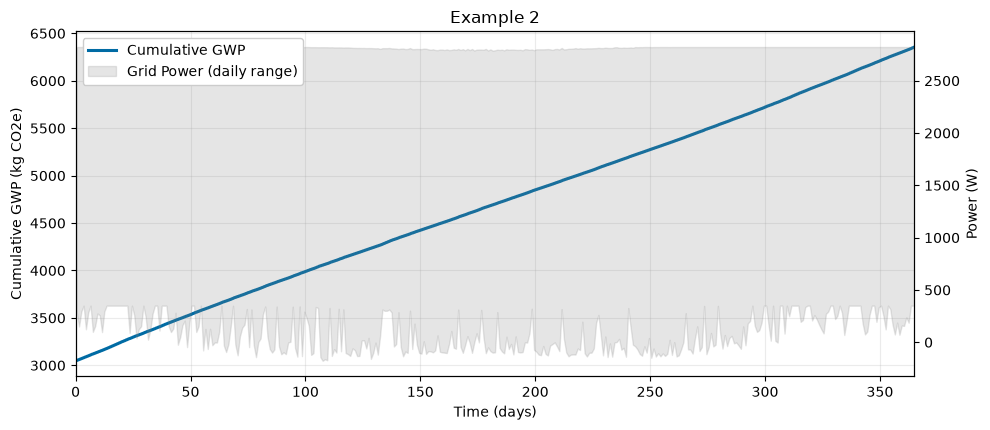

Example 2 summary
Samples (LCA): 8761
Final cumulative GWP: 6356 kg CO2e
Integrated power input: 9.545 MWh


In [65]:
# Co-simulate the two FMUs for one year
sys2, lca2 = sequential_cosim(
    system_fmu=PV_WECC_FMU,
    lca_fmu=LCA_WECC_FMU,
    start_s=0.0,
    stop_s=SECONDS_PER_YEAR,
    system_output="gri.P.real",
    n_pv=1.0,
    output_interval_s=3600.0,
 )

# Extract series
time_days = np.array(lca2["time"], dtype=np.float64) / SECONDS_PER_DAY
gwp = np.array(lca2["y"], dtype=np.float64)
energy_mwh = float(np.trapezoid(np.array(lca2["u"], dtype=np.float64), np.array(lca2["time"], dtype=np.float64)) / 3.6e9)

# Daily envelope for grid P real
g = pd.DataFrame({
    "day": (np.array(sys2["time"], dtype=np.float64) // SECONDS_PER_DAY).astype(int),
    "p": np.array(sys2["gri.P.real"], dtype=np.float64),
}).groupby("day")["p"].agg(["min", "max"])
x_day = g.index.to_numpy(dtype=np.float64) + 0.5

# Plot cumulative GWP (left) + daily grid envelope (right)
fig, ax1 = plt.subplots(figsize=(10, 4.4))
ax1.plot(time_days, gwp, color="C0", linewidth=2.2, label="Cumulative GWP")
ax1.set(xlabel="Time (days)", ylabel="Cumulative GWP (kg CO2e)", title="Example 2", xlim=(0, 365))
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
ax2.fill_between(x_day, g["min"], g["max"], color="gray", alpha=0.2, label="Grid Power (daily range)")
ax2.set_ylabel("Power (W)")

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
leg = ax2.legend(h1 + h2, l1 + l2, loc="upper left", framealpha=1.0, facecolor="white")
leg.set_zorder(1000)

plt.tight_layout()
plt.show()

# Results summary
print("Example 2 summary")
print(f"Samples (LCA): {len(lca2)}")
print(f"Final cumulative GWP: {gwp[-1]:.0f} kg CO2e")
print(f"Integrated power input: {energy_mwh:.3f} MWh")

## Example 3: Parameterization and Scenarios
Compare two grid scenarios and two n_pv values:
- Scenario A: PV_System_WECC + PvWecc_Ipcc_v1.0
- Scenario B: PV_System_MRO + PvWecc_Ipcc_v1.0

Parameter sweep: n_pv in {1.0, 2.0}.

Output comparison: final cumulative GWP after one year.

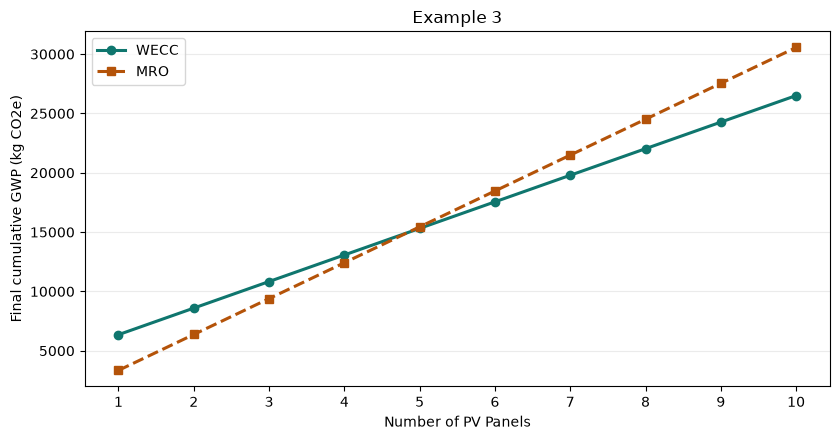

Example 3 Summary


,grid,n_pv,final_cumulative_gwp_kgco2e,energy_mwh
0,MRO,1.0,3347.824885,9.945368
1,MRO,2.0,6371.307252,8.121903
2,MRO,3.0,9394.789619,6.298438
3,MRO,4.0,12418.271985,4.474973
4,MRO,5.0,15441.754352,2.651508
5,MRO,6.0,18465.236718,0.828042
6,MRO,7.0,21488.719085,-0.995423
7,MRO,8.0,24512.201452,-2.818888
8,MRO,9.0,27535.683818,-4.642353
9,MRO,10.0,30559.166185,-6.465818


In [ ]:
systems = [
    ("WECC", PV_WECC_FMU, LCA_WECC_FMU),
    ("MRO", PV_MRO_FMU, LCA_MRO_FMU),
]

n_pv_values = np.linspace(1.0, 10.0, 10)

rows = []
for grid_name, system_fmu, lca_fmu in systems:
    for n_pv in n_pv_values:
        _, lca_res = sequential_cosim(
            system_fmu=system_fmu,
            lca_fmu=lca_fmu,
            start_s=0.0,
            stop_s=SECONDS_PER_YEAR,
            system_output="gri.P.real",
            n_pv=n_pv,
            output_interval_s=3600.0,
        )

        t = np.array(lca_res["time"], dtype=np.float64)
        u = np.array(lca_res["u"], dtype=np.float64)
        y = np.array(lca_res["y"], dtype=np.float64)
        rows.append({
            "grid": grid_name,
            "n_pv": n_pv,
            "final_cumulative_gwp_kgco2e": float(y[-1]),
            "energy_mwh": float(np.trapezoid(u, t) / 3.6e9),
        })

# Save sorted results to dataframe
df3 = pd.DataFrame(rows).sort_values(["grid", "n_pv"]).reset_index(drop=True)

# Plot
fig, ax = plt.subplots(figsize=(8.5, 4.5))
style_map = {
    "WECC": {"color": "C0", "linestyle": "-", "marker": "o"},
    "MRO":  {"color": "C1", "linestyle": "--", "marker": "s"},
}
# Plot final cumulative GWP vs n_pv for each grid scenario
for grid_name in ["WECC", "MRO"]:
    subset = df3[df3["grid"] == grid_name].sort_values("n_pv")
    style = style_map[grid_name]
    ax.plot(
        subset["n_pv"],
        subset["final_cumulative_gwp_kgco2e"],
        color=style["color"],
        linestyle=style["linestyle"],
        marker=style["marker"],
        markersize=6,
        linewidth=2.2,
        label=grid_name,
    )
# Plot settings
ax.set_xlabel("Number of PV Panels")
ax.set_ylabel("Final cumulative GWP (kg CO2e)")
ax.set_xticks(n_pv_values)
ax.set_xticklabels([f"{v:g}" for v in n_pv_values])
ax.set_title("Example 3")
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

# Summary table
print("Example 3 Summary")
display(df3)

# Bonus
Scripts to generate LCA FMUs

In [ ]:
# Set up BW project with ecoinvent database (3.12)


In [12]:
# Convert inventory CSVs to JSON file
import scripts.csv_to_json_translator as c2j

# Example usage
c2j.convert_csv_to_lci_json_flexible(csv_files="data/lci.csv")

Converting CSV to LCI JSON using flexible configuration...
   Input: data\lci.csv
   Output: data\lci.json
🔄 Importing LCI data...
   📁 File: data\lci.csv
   📋 Format: csv
Error during conversion: No CSV data lines found in file: data\lci.csv


In [6]:
# Run the LCA with lca_engine
import src.lca_engine as lca

# Example usage
results = lca.run_lca(lci_file="lci.json", lcia_methods="IPCC")

❌ Error in run_lca_energy: [Errno 2] No such file or directory: 'lci.json'
Traceback:


Traceback (most recent call last):
  File "c:\Users\khinkelm\.conda\envs\brightcon2026\Lib\site-packages\src\lca_engine.py", line 346, in run_lca_energy
    with open(lci_file, 'r') as f:
         ^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'lci.json'


In [ ]:
# Create the LCA FMU

In [ ]:
# Inspect and test run the newly created LCA FMU

# That's all for now!

Questions/comments? 
